In [1]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## Run python script for auto-generating flux response to varyinh nH 

In [2]:
# Flux response table to nH absorption
os.system("python compute_flux_vs_nH.py \
--specdir data/ind_spectrum/15803 \
--band broad soft medium hard --out_csv ./analyses/flux_vs_nH_tbabs_15803_all_bands.csv \
--out_png ./analyses/flux_vs_nH_tbabs_15803_all_bands.png \
--model tbabs \
--statistic cstat \
--init_nH=0.589454 \
--fit_emin 0.5 --fit_emax 7.0 \
--init_PhoIndex=1.92146 \
--init_norm=3.37606e-04")


1 spectrum  in use
 
Spectral Data File: 15803.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.230e-01 +/- 9.594e-04 (99.6 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 1.343e+05 sec
 Using fit statistic: chi
 Using Background File                15803_bkg.pi
  Background Exposure Time: 1.343e+05 sec
 Using Response (RMF) File            15803.rmf for Source 1
 Using Auxiliary Response (ARF) File  15803.arf

Net count rate (cts/s) for Spectrum:1  1.230e-01 +/- 9.594e-04 (99.6 % total)
 Solar Abundance Vector set to wilm:  Wilms, J., Allen, A. & McCray, R. ApJ 542 914 (2000) (abundances are set to zero for those elements not included in the paper).
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996
Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.

Model TBabs<1>*powerlaw<2> Source No.: 1   

/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/compute_flux_vs_nH.py:498: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ph = float(np.trapz(y_b, E_b))
/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/compute_flux_vs_nH.py:499: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  erg = float(np.trapz(E_b * y_b, E_b)) * _KEV_TO_ERG



Fit statistic  : C-Statistic                 9671.93     using 446 bins.

Test statistic : Chi-Squared                42844.70     using 446 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 445 degrees of freedom
 Current data and model not fit yet.

Models will now use energy array created from:
   0.1 - 20   2000 log bins


Fit statistic  : C-Statistic                 9671.93     using 446 bins.

Test statistic : Chi-Squared                42844.70     using 446 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 445 degrees of freedom
 Current data and model not fit yet.

Models will now use energy array created from:
   0.1 - 20   2000 log bins


Fit statistic  : C-Statistic                 9671.93     using 446 bins.

Test statistic : Chi-Squared             

0

## Spectrum Model for ObsID 15803

In [4]:
# 15803 Spectrum fitting
specdir = "data/ind_spectrum/15803"
instrument = "chandra"
src, bkg, rmf, arf = find_spectrum_files(specdir)
load_xspec_spectrum(src, bkg, rmf, arf)


1 spectrum  in use
 
Spectral Data File: 15803.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.230e-01 +/- 9.594e-04 (99.6 % total)
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: CHANDRA Instrument: ACIS  Channel Type: PI
  Exposure Time: 1.343e+05 sec
 Using fit statistic: chi
 Using Background File                15803_bkg.pi
  Background Exposure Time: 1.343e+05 sec
 Using Response (RMF) File            15803.rmf for Source 1
 Using Auxiliary Response (ARF) File  15803.arf

Net count rate (cts/s) for Spectrum:1  1.230e-01 +/- 9.594e-04 (99.6 % total)


In [5]:
AllData.ignore("**-0.5, 7.0-**")

    35 channels (1-35) ignored in spectrum #     1
   545 channels (480-1024) ignored in spectrum #     1



Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.


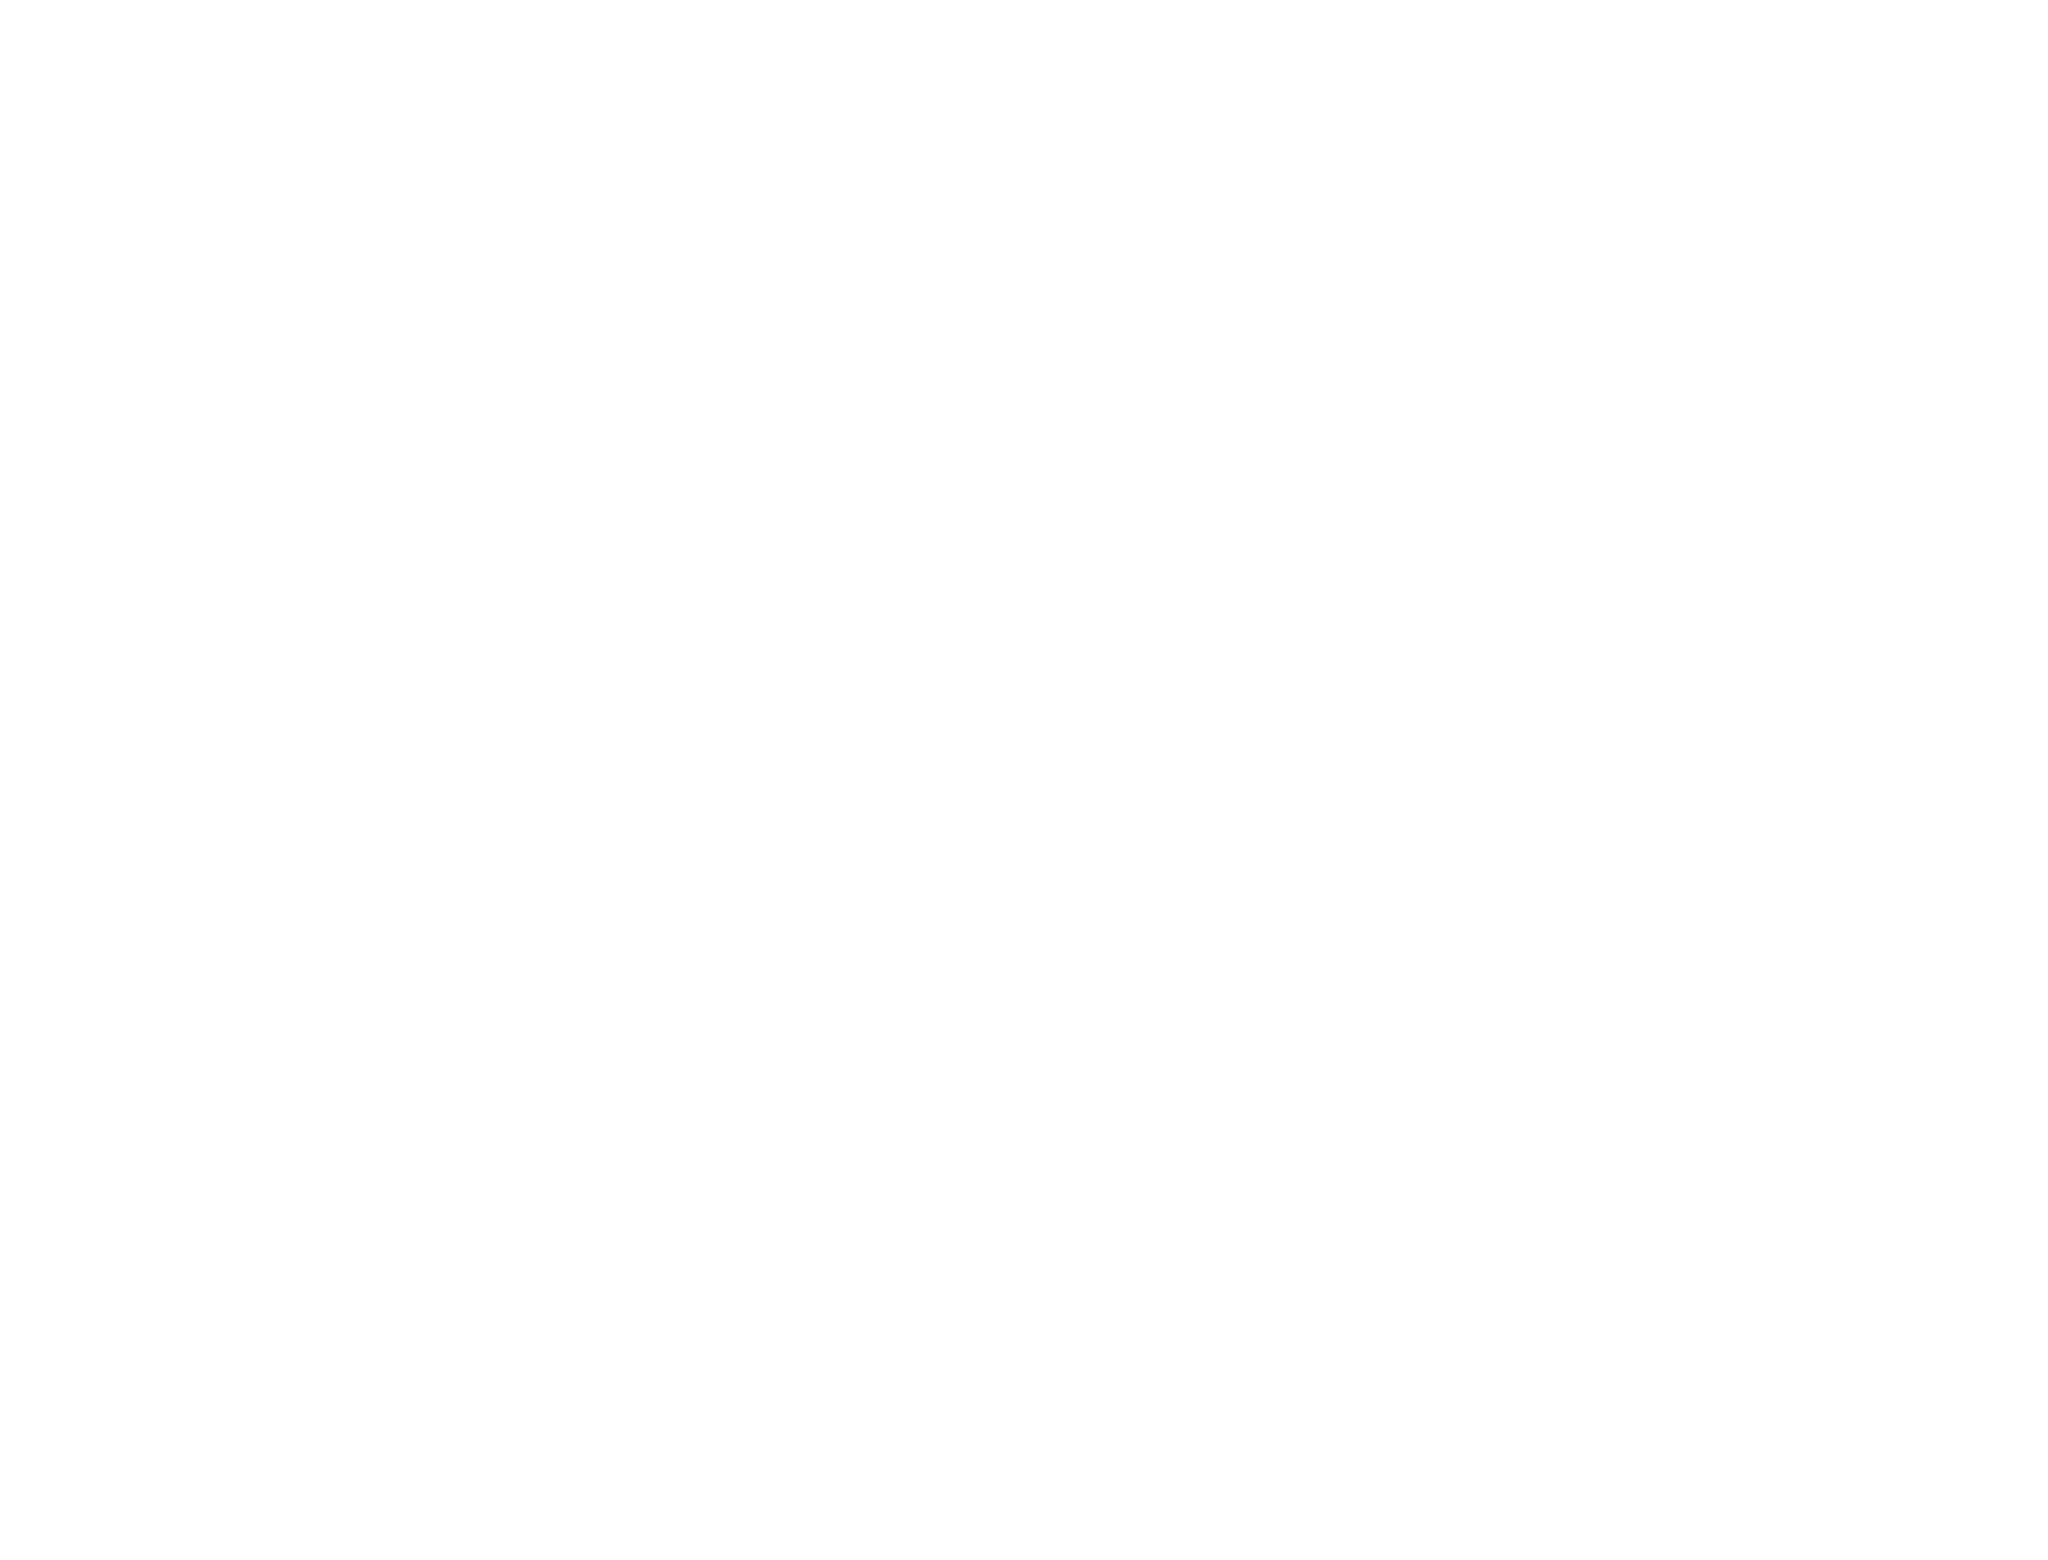

In [6]:
AllModels.clear()
Fit.statMethod = "cstat"
# Plot spectrum data
Plot.device = "/svg"
Plot.xAxis = "KeV"
Plot("data")

In [7]:
# Load an absorber model with powerlaw
m1 = Model("tbabs*(po)")
m1.powerlaw.PhoIndex = 1.92146
m1.powerlaw.norm = 3.37606e-04
m1.TBabs.nH = 0.589454
m1.show()


Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   powerlaw   PhoIndex            1.00000      +/-  0.0          
   3    2   powerlaw   norm                1.00000      +/-  0.0          
________________________________________________________________________

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Fit statistic  : C-Statistic              1.203313e+08     using 444 bins.

In [8]:
Fit.nIterations = 500
Fit.perform()
Fit.show()

                                   Parameters
C-Statistic  |beta|/N    Lvl          1:nH    2:PhoIndex        3:norm
1203.43      6.17722e+06  -3      0.571280       2.09253   0.000504444
556.83       1.96941e+06  -4      0.545642       2.14996   0.000607306
530.974      339583       -5      0.533980       2.15269   0.000625986
530.945      10809.2      -6      0.533345       2.15258   0.000626410
530.945      9.578         0      0.533345       2.15258   0.000626410
 Variances and Principal Axes
                 1        2        3  
 2.3971E-11| -0.0005  -0.0004   1.0000  
 7.5911E-05|  0.8670  -0.4984   0.0002  
 1.1809E-03|  0.4984   0.8670   0.0006  
----------------------------------------

  Covariance Matrix
        1           2           3   
   3.504e-04   4.774e-04   3.832e-07
   4.774e-04   9.064e-04   6.367e-07
   3.832e-07   6.367e-07   4.944e-10
------------------------------------

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  U

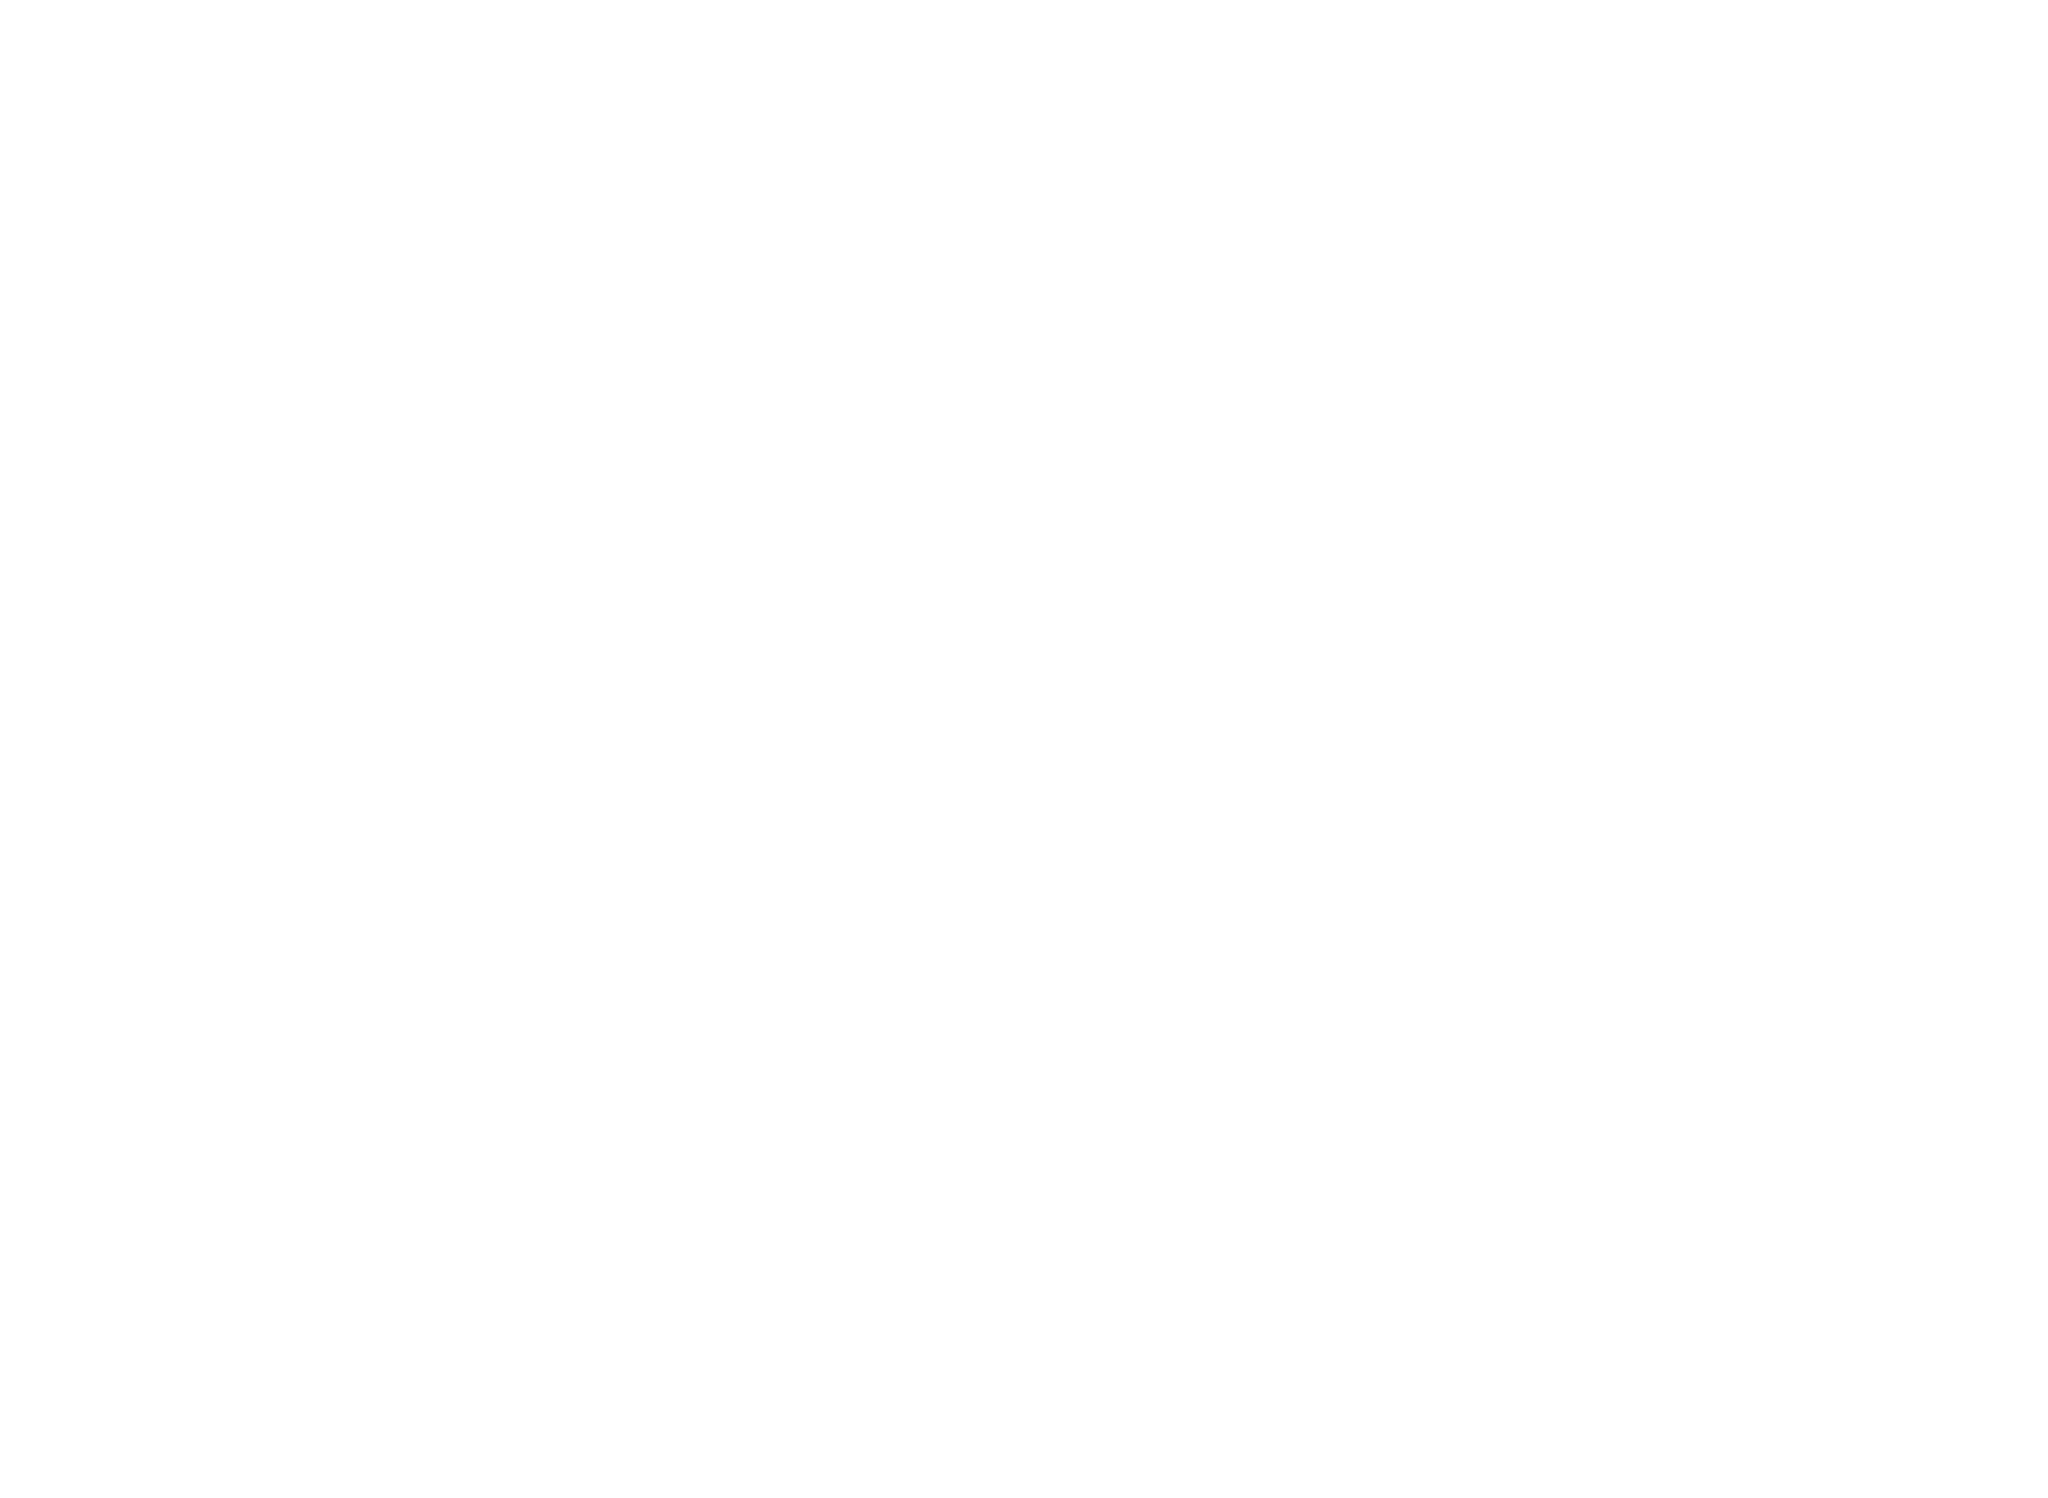

In [9]:
Plot("data resid")

## Manual curation of flux response to varying nH parameters using spectrum fit

In [10]:
# save Fit parameters
par1 = m1.TBabs.nH
par2 = m1.powerlaw.PhoIndex
par3 = m1.powerlaw.norm

# Freeze parameters other than nH
par2.frozen = True
par3.frozen = True
m1.show()


Fit statistic  : C-Statistic                  530.94     using 444 bins.

Test statistic : Chi-Squared                 1829.11     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 1.10e-167 with 442 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : C-Statistic                  530.94     using 444 bins.

Test statistic : Chi-Squared                 1829.11     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 2.24e-167 with 443 degrees of freedom
 Current data and model not fit yet.

Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.533345     +/-  1.87181E-02  
   2    2   powerlaw   PhoIndex            2.15258      frozen
   3    2   powe

### Soft Band

In [9]:
instrument_bands = {
    "broad": (0.5, 7.0),
    "soft": (0.5, 2.0),
    "medium": (1.2, 2.0),
    "hard": (2.0, 7.0),
}
#out_csv = ""
#band_names = ["broad","soft","medium","hard"]
band_names = ["soft"]
bands = {name: instrument_bands[name] for name in band_names}
# Build nH grid (log-spaced)
nH_values_cm2 = np.logspace(np.log10(1e20), np.log10(1e24), 60)
df = vary_nh_and_compute(nH_values_cm2, bands)


Froze powerlaw parameters (PhoIndex, norm) using parameter indices

Computing flux for 60 nH values...
  parameter 2 is already frozen.
  parameter 3 is already frozen.

Fit statistic  : C-Statistic                10625.82     using 444 bins.

Test statistic : Chi-Squared                47166.77     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.

Models will now use energy array created from:
   0.1 - 20   2000 log bins


Fit statistic  : C-Statistic                10625.13     using 444 bins.

Test statistic : Chi-Squared                47145.90     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : C-Sta

In [15]:
df.to_csv("./analyses/flux_vs_nH_tbabs_15803_soft.csv", index=False)

In [10]:
df.head(10)

,nH_cm2,nH_1e22,flux_soft_ph,flux_soft_erg
0,1.000000e+20,0.010000,0.000919,1.343539e-12
1,1.168952e+20,0.011690,0.000912,1.335891e-12
2,1.366448e+20,0.013664,0.000904,1.327038e-12
3,1.597312e+20,0.015973,0.000895,1.316807e-12
4,1.867181e+20,0.018672,0.000885,1.305007e-12
5,2.182645e+20,0.021826,0.000873,1.291427e-12
6,2.551407e+20,0.025514,0.000859,1.275838e-12
7,2.982471e+20,0.029825,0.000844,1.257995e-12
8,3.486365e+20,0.034864,0.000826,1.237643e-12
9,4.075393e+20,0.040754,0.000806,1.214521e-12


In [11]:
df.tail(10)

,nH_cm2,nH_1e22,flux_soft_ph,flux_soft_erg
50,2.453751e+23,24.537511,1.615943e-10,4.980689e-19
51,2.868317e+23,28.683168,2.105857e-11,6.524573e-20
52,3.352924e+23,33.529241,1.998905e-12,6.223434e-21
53,3.919407e+23,39.194068,1.312846e-13,4.105722e-22
54,4.581598e+23,45.815977,5.616517e-15,1.763465e-23
55,5.355667e+23,53.556669,1.457386e-16,4.591509e-25
56,6.260517e+23,62.605166,2.108182e-18,6.660652e-27
57,7.318242e+23,73.182422,1.539067e-20,4.873673e-29
58,8.554673e+23,85.546725,5.045075e-23,1.600496e-31
59,1.000000e+24,100.000000,6.476886e-26,2.057709e-34


In [17]:
# Verify few values manually
m1.TBabs.nH = 0.040754
AllModels.calcFlux("0.5 2.0")


Fit statistic  : C-Statistic                 9061.44     using 444 bins.

Test statistic : Chi-Squared                35197.54     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.
 Model Flux 0.00080905 photons (1.2174e-12 ergs/cm^2/s) range (0.50000 - 2.0000 keV)


In [20]:
AllModels.show()


Parameters defined:
Model TBabs<1>*powerlaw<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    0.533551     +/-  7.09471E-03  
   2    2   powerlaw   PhoIndex            2.15258      frozen
   3    2   powerlaw   norm                6.26410E-04  frozen
________________________________________________________________________



### Broad band

In [11]:
instrument_bands = {
    "broad": (0.5, 7.0),
    "soft": (0.5, 2.0),
    "medium": (1.2, 2.0),
    "hard": (2.0, 7.0),
}
band_names = ["broad"]
bands = {name: instrument_bands[name] for name in band_names}
# Build nH grid (log-spaced)
nH_values_cm2 = np.logspace(np.log10(1e20), np.log10(1e24), 60)
df = vary_nh_and_compute(nH_values_cm2, bands)


Froze powerlaw parameters (PhoIndex, norm) using parameter indices  parameter 2 is already frozen.
  parameter 3 is already frozen.


Computing flux for 60 nH values...

Fit statistic  : C-Statistic                10625.82     using 444 bins.

Test statistic : Chi-Squared                47166.77     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.

Models will now use energy array created from:
   0.1 - 20   2000 log bins


Fit statistic  : C-Statistic                10625.13     using 444 bins.

Test statistic : Chi-Squared                47145.90     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : C-Sta

In [13]:
df.to_csv("./analyses/flux_vs_nH_tbabs_15803_broad.csv", index=False)

In [14]:
df.head()

,nH_cm2,nH_1e22,flux_broad_ph,flux_broad_erg
0,1.000000e+20,0.010000,0.001105,2.372081e-12
1,1.168952e+20,0.011690,0.001099,2.364199e-12
2,1.366448e+20,0.013664,0.001091,2.355072e-12
3,1.597312e+20,0.015973,0.001082,2.344521e-12
4,1.867181e+20,0.018672,0.001071,2.332347e-12


In [17]:
# Verify few values manually
m1.TBabs.nH = 0.018672
AllModels.calcFlux("0.5 7.0")


Fit statistic  : C-Statistic                10162.35     using 444 bins.

Test statistic : Chi-Squared                43375.27     using 444 bins.

***Warning: Chi-square may not be valid due to bins with zero variance
            in spectrum number(s): 1 

 Null hypothesis probability of 0.00e+00 with 443 degrees of freedom
 Current data and model not fit yet.
 Model Flux 0.0010743 photons (2.3353e-12 ergs/cm^2/s) range (0.50000 - 7.0000 keV)
